Here, we compare probabilistic modeling of eigenvectors into A/B compartment calls for Hi-C data. 

We compare different models, all using the same underlying structure, but varying smaller aspects of the model. 

## Goals

To quantify differences in model performance, we use the following metrics:

- WAIC: Widely Applicable Information Criterion, a measure of model fit that penalizes complexity.

- LOO: Leave-One-Out Cross-Validation, a method for estimating the predictive accuracy of a model.

We also try to assign uncertainty to the compartment calls, ultimately defining credible intervals for the compartment transitions. 

## Imports and setup

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib_inline
import pymc as pm
import arviz as az
import pytensor.tensor as pt
from scipy.stats import norm, t
from pprint import pprint

## Use a custom style for the plots
plt.style.use('smaller.mplstyle')
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
#%config InlineBackend.figure_formats = ['retina']


## Load/show data

Here, we load the Hi-C contact matrix and the first eigenvector (E1) of the contact matrix. The E1 is used as a predictor for compartment assignment.

The eigendecomposition of the Hi-C matrix was performed with the workflow in the main folder (`workflow.py`), using the **Open2C** ecosystem

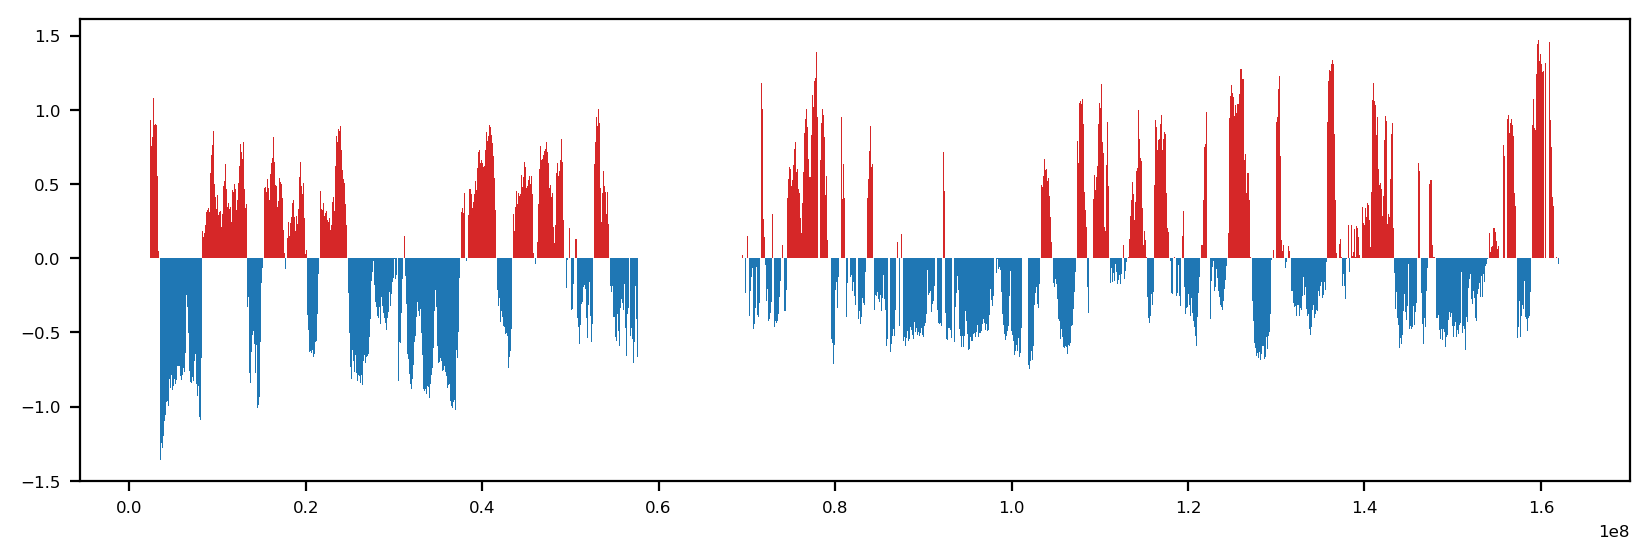

In [12]:
# Load the data
resolution = 100000

y = pd.Series(pd.read_csv(f"../data/eigs/fibroblast.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
x = pd.Series(np.arange(0,y.shape[0])*resolution)

# Make a DataFrame object
df = pd.DataFrame({"start": x, "e1": y})


# Plot the data

fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(df.start, df.e1, where=df.e1 > 0, color='tab:red', ec='None', label='E1', step='pre')
ax.fill_between(df.start, df.e1, where=df.e1 < 0, color='tab:blue', ec='None', label='E1', step='pre') 

df.dropna(inplace=True)

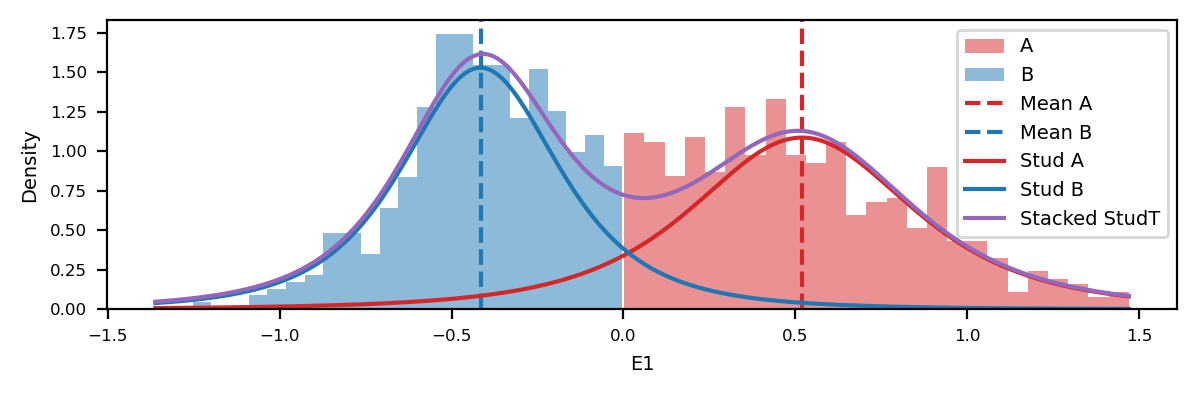

In [13]:
# Histogram of distribution of E1 values (A and B)


x = df["start"].values
y = df["e1"].values
dist_x_values = np.linspace(y.min(), y.max(), 1000)
a_dist = t.pdf(dist_x_values, loc=np.mean(y[y>0]), scale=y[y>0].std(), df=3)
b_dist = t.pdf(dist_x_values, loc=np.mean(y[y<0]), scale=y[y<0].std(), df=3)


f, ax = plt.subplots()

# A compartments
ax.hist(y[y>0], bins=25, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=25, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
ax.plot(dist_x_values, a_dist, color="tab:red", label="Stud A")
ax.plot(dist_x_values, b_dist, color="tab:blue", label="Stud B")
ax.plot(dist_x_values, a_dist+b_dist, color="tab:purple", label="Stacked StudT")

# Final touches
plt.xlabel("E1")
plt.ylabel("Density")
plt.legend(loc='best')
plt.tight_layout()

Here, the observed distributions are compared to StudenT distributions of 3 degrees of freedom and the same mean and standard deviation as the observed data. The Student's t-distribution is used because it is more robust with its heavier tails than the normal. 

## Models

Here, we expand on the results from `03_PyMC_GRW_logit.ipynb`, and use the same model structure, but with different priors and likelihoods. Overall, the following thoughts are implemented:

- We assume that the eigenvectors can be drawn from a mixture of two distributions, one for each compartment (A and B). It could be any mixture, but the means should be negative for B and positive for A. We use either to model `mu`:
    - Gaussians, as a simple starting point, or 
    - Student's t-distributions, as a heavier-tailed alternative.
    - The mixtures has to be ordered in PyMC to ensure that the A compartment is always positive and the B compartment is always negative.
- The mixture components have their own (learned) standard deviation, `sigma`. 
- The mixture components use `mu` and `sigma` (each of shape 2) in either a,
    - Normal distribution, or
    - Student's t-distribution, with 10 degrees of freedom.
- We model the mixture weight as a *non-centered* (Gaussian) random walk prior, as a method of probabilistic smoothing of the PCA compartment calls.
    - `eps` is the (learned) step size of the random walk, and
        - either Normal or Student's t-distributed
    - `grw_sigma` is the (learned) standard deviation of the random walk
        - either HalfNormal or HalfStudentT-distributed
    - The logit-space (of the mixture weight) is then modeled *deterministically* as the cummulative sum of the random walk steps. 
    - The logit-space is then transformed to the probability space by squishing it through a sigmoid function.
- $\hat{y}$ (`y_hat`) is drawing the observations from the mixture distribution, using the mixture weight and the two components (the learned distributions of E1 values for A and B-compartments).

### Model 1: T-dist in logit space, T-dist in mixture components

In [14]:
import pytensor.tensor as pt

with pm.Model(coords={"pos": df.index.values}) as latentT_Tmix_model:
    e1 = pm.Data("e1", df.e1.values, dims="pos")

    # Ordered parameters for the means of the two components
    # Note: The ordered transform ensures that mu_a < mu_b
    mu = pm.Normal("mu", mu=[-0.5, 0.5], sigma=0.3,
        transform=pm.distributions.transforms.ordered, # IMPORTANT
        shape=2,
        )
    sigma = pm.HalfNormal("sigma", 0.3, shape=2)

    # GRW over logit space; non-centered reparameterization
    grw_sigma = pm.HalfNormal("grw_sigma", 0.05)

    # StudentT distribution for eps (got alot of divergences with nu=3)
    eps = pm.StudentT("eps", nu=10, mu=0.0, sigma=1.0, dims="pos")
    
    # Cumulative sum to create a Gaussian Random Walk
    logit_w = pm.Deterministic("logit_w", pt.cumsum(eps * grw_sigma), dims="pos")
    w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

    # Components of the mixture model
    components = pm.StudentT.dist(nu=10, mu=mu, sigma=sigma, shape=2)

    # Mixture model
    # The observed data is modeled as a mixture of the two components
    y_hat = pm.Mixture("y_hat", w=pm.math.stack([w,1-w], axis=1), comp_dists=components, observed=e1, dims='pos')


### Model 1: T-dist in logit space, Normal in mixture components

In [15]:
with pm.Model(coords={"pos": df.index.values}) as latentT_Nmix_model:
    e1 = pm.Data("e1", df.e1.values, dims="pos")

    # Ordered parameters for the means of the two components
    # Note: The ordered transform ensures that mu_a < mu_b
    mu = pm.Normal("mu", mu=[-0.5, 0.5], sigma=0.3,
        transform=pm.distributions.transforms.ordered, # IMPORTANT
        shape=2,
        )
    sigma = pm.HalfNormal("sigma", 0.3, shape=2)

    # GRW over logit space; non-centered reparameterization
    grw_sigma = pm.HalfNormal("grw_sigma", 0.05)

    # StudentT distribution for eps (got alot of divergences with nu=3)
    eps = pm.StudentT("eps", nu=10, mu=0.0, sigma=1.0, dims="pos")
    
    # Cumulative sum to create a Gaussian Random Walk
    logit_w = pm.Deterministic("logit_w", pt.cumsum(eps * grw_sigma), dims="pos")
    w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

    # Components of the mixture model
    components = pm.StudentT.dist(nu=10, mu=mu, sigma=sigma, shape=2)

    # Mixture model
    # The observed data is modeled as a mixture of the two components
    y_hat = pm.Mixture("y_hat", w=pm.math.stack([w,1-w], axis=1), comp_dists=components, observed=e1, dims='pos')

### Parameter sweep configuration

Here is an attempt to sweep through parameters in a reproducible and deterministic way. The idea is to use a grid search over the parameters, and then run the models in parallel, and finally collect the results and analyze them.

First, let's create a function that create a grid of parameters to sweep over using itertools.

#### Create parameter grid

In [16]:
import itertools as it

def create_model_grid():
    """
    Create a grid of models for the different configurations as defined below.
    Name the model according to the configuration for easier identification:
    - comp_dist: Distribution of the components (Normal or StudentT)
    - eps_dist: Distribution of the GRW steps (Normal or StudentT)
    - grw_sigma_dist: Distribution of the GRW noise (HalfNormal or HalfStudentT)
    name = f"{comp_dist}_{eps_dist}_{grw_sigma_dist}"
    - If any distribution is StudentT, append the nu parameter to the name.
    """

    def config_namer(comp_dist, comp_kwargs, eps_dist, eps_kwargs, grw_sigma_dist, grw_sigma_kwargs):
        abbr = {
            'Normal': 'N',
            'StudentT': 'T',
            'HalfNormal': 'HN',
            'HalfStudentT': 'HT'
        }

        name = f"{abbr[comp_dist]}_{abbr[eps_dist]}_{abbr[grw_sigma_dist]}"
        if comp_dist == 'StudentT':
            name += f"_{comp_kwargs['nu']}"
        if eps_dist == 'StudentT':
            name += f"_{eps_kwargs['nu']}"
        if grw_sigma_dist == 'HalfStudentT':
            name += f"_{grw_sigma_kwargs['nu']}"
        return name
    
    comp_kwargs_list = [
    ('Normal', {}),
    ('StudentT', {'nu': 10}),
    ('StudentT', {'nu': 5})
    ]

    eps_kwargs_list = [
        ('Normal', {'mu': 0.0, 'sigma': 1.0}),
        ('StudentT', {'nu': 10, 'mu': 0.0, 'sigma': 1.0}),
        ('StudentT', {'nu': 5, 'mu': 0.0, 'sigma': 0.5})
    ]

    grw_sigma_kwargs_list = [
        ('HalfNormal', {'sigma': 0.05}),
        ('HalfStudentT', {'nu': 10, 'sigma': 0.05}),
        ('HalfStudentT', {'nu': 5, 'sigma': 0.01})
    ]


    # Prior configurations for E1 mixture
    mu_mu = [-0.5, 0.5]
    mu_sigma = 0.3
    sigma = 0.3

    grid = it.product(comp_kwargs_list, eps_kwargs_list, grw_sigma_kwargs_list)
    configs = []
    for (comp_dist, comp_kwargs), (eps_dist, eps_kwargs), (grw_sigma_dist, grw_sigma_kwargs) in grid:
        name = config_namer(
            comp_dist, comp_kwargs, 
            eps_dist, eps_kwargs, 
            grw_sigma_dist, grw_sigma_kwargs
            )
        config = {
            'name': name,
            'comp_dist': comp_dist,
            'comp_kwargs': comp_kwargs,
            'eps_dist': eps_dist,
            'eps_kwargs': eps_kwargs,
            'grw_sigma_dist': grw_sigma_dist,
            'grw_sigma_kwargs': grw_sigma_kwargs,
            'mu_mu': mu_mu,
            'mu_sigma': mu_sigma,
            'sigma': sigma
        }
        configs.append(config)
    return configs



In [18]:
from pprint import pprint
import json
# Instantiate the model grid
configs = create_model_grid()

pprint(configs)

# Save the model grid to a JSON file
with open("../results/model_grid.json", "w") as f:
    json.dump(configs, f, indent=4)

[{'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'Normal',
  'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
  'grw_sigma_dist': 'HalfNormal',
  'grw_sigma_kwargs': {'sigma': 0.05},
  'mu_mu': [-0.5, 0.5],
  'mu_sigma': 0.3,
  'name': 'N_N_HN',
  'sigma': 0.3},
 {'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'Normal',
  'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
  'grw_sigma_dist': 'HalfStudentT',
  'grw_sigma_kwargs': {'nu': 10, 'sigma': 0.05},
  'mu_mu': [-0.5, 0.5],
  'mu_sigma': 0.3,
  'name': 'N_N_HT_10',
  'sigma': 0.3},
 {'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'Normal',
  'eps_kwargs': {'mu': 0.0, 'sigma': 1.0},
  'grw_sigma_dist': 'HalfStudentT',
  'grw_sigma_kwargs': {'nu': 5, 'sigma': 0.01},
  'mu_mu': [-0.5, 0.5],
  'mu_sigma': 0.3,
  'name': 'N_N_HT_5',
  'sigma': 0.3},
 {'comp_dist': 'Normal',
  'comp_kwargs': {},
  'eps_dist': 'StudentT',
  'eps_kwargs': {'mu': 0.0, 'nu': 10, 'sigma': 1.0},
  'grw_sigma_dist': 'HalfNormal',
  'grw_sigma_kw

#### Create model builder function

Then, we want to create a function (model_builder) that takes the parameters and returns a PyMC model. This function will be used to build the models in parallel.


In [8]:
def build_model_from_config(df, cfg):
    """
    Build a PyMC model based on the provided configuration dictionary.
    """

    with pm.Model(coords={"pos": df.index.values}) as model:
        e1 = pm.Data("e1", df.e1.values, dims="pos")

        mu = pm.Normal("mu", mu=cfg['mu_mu'], sigma=cfg['mu_sigma'],
                       transform=pm.distributions.transforms.ordered, shape=2)
        sigma = pm.HalfNormal("sigma", sigma=cfg['sigma'], shape=2)

        # components: Normal or StudentT
        if cfg['comp_dist'] == "Normal":
            components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)
        else:
            components = pm.StudentT.dist(mu=mu, sigma=sigma, **cfg['comp_kwargs'], shape=2)

        # grw_sigma: HalfNormal or HalfStudentT
        if cfg['grw_sigma_dist'] == "HalfNormal":
            grw_sigma = pm.HalfNormal("grw_sigma", **cfg['grw_sigma_kwargs'])
        else:
            grw_sigma = pm.HalfStudentT("grw_sigma", **cfg['grw_sigma_kwargs'])

        # eps: Normal or StudentT
        if cfg['eps_dist'] == "Normal":
            eps = pm.Normal("eps", dims="pos", **cfg['eps_kwargs'])
        else:
            eps = pm.StudentT("eps", dims="pos", **cfg['eps_kwargs'])

        logit_w = pm.Deterministic("logit_w", pt.cumsum(eps * grw_sigma), dims="pos")
        w = pm.Deterministic("w", pm.math.sigmoid(logit_w), dims="pos")

        y_hat = pm.Mixture("y_hat", w=pt.stack([w, 1-w], axis=1), comp_dists=components,
                           observed=e1, dims='pos')

    return model


#### Sampling loop

Now, we create the sampling loop that should run the models in sequence.

We will name the models by joining the list `[number, comp_dist, eps_dist, grw_sigma_dist][eps_nu, comp_nu]`.

All the traces (InferenceData) will be saved in a dictionary, `model_traces`.

##### Sample the models

In [ ]:
from datetime import datetime

def log(msg, path=".04_PyMC_GRW_compare.log", overwrite=False):
    print(f"LOG: {msg}")
    if overwrite:
        with open(path, "w") as f:
            f.write(msg + "\n")
    else:
        with open(path, "a") as f:
            f.write(msg + "\n")


# Reset the log file
log("Resetting log... \n", overwrite=True)

model_traces = {}

for i, cfg in enumerate(configs):
    name = cfg['name']
    
    if name in model_traces:
        continue
    else:
        model_traces[name] = {'model': None, 'trace': None, 'scores': None}


    log(f"Sampling {name}...")
    try:
        start = datetime.now()
        log(f"Started at {start.strftime('%H:%M:%S')}")
        model_traces[name]['model'] = build_model_from_config(df, cfg)
        model = model_traces[name]['model']
        trace = pm.sample(draws=1000, tune=1000, chains=7, cores=7, progressbar=False, model=model)
        model_traces[name]['trace'] = trace
        log(f"--> Took {(datetime.now()-start).total_seconds()} seconds!\n")
    except Exception as e:
        log(f"Model {name} failed: {e}\n")


LOG: Resetting log... 

LOG: Sampling N_N_HN...
LOG: Started at 16:23:36


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (7 chains in 7 jobs)


NUTS: [mu, sigma, grw_sigma, eps]


Sampling 7 chains for 1_000 tune and 1_000 draw iterations (7_000 + 7_000 draws total) took 205 seconds.


...

Sampling 7 chains for 1_000 tune and 1_000 draw iterations (7_000 + 7_000 draws total) took 59 seconds.


There were 6998 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


LOG: --> Took 66.229913 seconds!



In [10]:
model_traces.items()

dict_items([('N_N_HN', {'model': <pymc.model.core.Model object at 0x147c288d5a90>, 'trace': Inference data with groups:
	> posterior
	> sample_stats
	> observed_data, 'scores': None}), ('N_N_HT_10', {'model': <pymc.model.core.Model object at 0x147c22fb29e0>, 'trace': Inference data with groups:
	> posterior
	> sample_stats
	> observed_data, 'scores': None}), ('N_N_HT_5', {'model': <pymc.model.core.Model object at 0x147c22fb2b10>, 'trace': Inference data with groups:
	> posterior
	> sample_stats
	> observed_data, 'scores': None}), ('N_T_HN_10', {'model': <pymc.model.core.Model object at 0x147c22fb1e00>, 'trace': Inference data with groups:
	> posterior
	> sample_stats
	> observed_data, 'scores': None}), ('N_T_HT_10_10', {'model': <pymc.model.core.Model object at 0x147c4efccfc0>, 'trace': Inference data with groups:
	> posterior
	> sample_stats
	> observed_data, 'scores': None}), ('N_T_HT_10_5', {'model': <pymc.model.core.Model object at 0x147c4efcd0f0>, 'trace': Inference data with grou

##### Log-lik, WAIC and PPC

In [11]:
for name, model_dict in model_traces.items():
    # model_dict.keys(): {'model', 'trace', 'scores'}

    try:
        print(name)
        pm.compute_log_likelihood(
            model_dict['trace'], 
            model=model_dict['model'], 
            progressbar=False)
    except Exception as e:
        print(f"{name} failed computing log_likelihood: {e}")    
    try:
        prior_predictive = pm.sample_prior_predictive(
            1000, 
            model=model_dict['model'])
        model_dict['trace'].extend(prior_predictive)
    except Exception as e:
        print(f"{name} failed sampling prior predictive: {e}")
    try:
        posterior_predictive = pm.sample_posterior_predictive(
            model_dict['trace'], 
            model=model_dict['model'], 
            progressbar=False)
        model_dict['trace'].extend(posterior_predictive)
    except Exception as e:
        print(f"{name} failed sampling posterior predictive: {e}")

    try:
        loo = az.loo(model_dict['trace'])
        waic = az.waic(model_dict['trace'])
        model_dict['scores'] = {
            "loo": loo,
            "waic": waic
        }
    except Exception as e:
        print(f"{name} failed during loo/waic: {e}")


N_N_HN


Sampling: [eps, grw_sigma, mu, sigma, y_hat]


Sampling: [y_hat]


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


...

T_T_HT_5_5_5


Sampling: [eps, grw_sigma, mu, sigma, y_hat]


Sampling: [y_hat]


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1655: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


#### Save the results

In [12]:
import os.path as op
import os
import cloudpickle

# Save the traces to file (netcdf)

dir = "../results"

for name, d in model_traces.items():
    # Save the model.Model as a cloudpickle.dumps
    os.makedirs(op.join(dir, "models"), exist_ok=True)
    model_path = op.join(dir, "models", f"{name}_model.pkl")
    # print(model_path)
    with open(model_path, "wb") as f:
        cloudpickle.dump(d['model'], f)

    # Save the trace as a netcdf file
    trace_path = op.join(dir, "traces", f"{name}_trace.nc")
    os.makedirs(op.dirname(trace_path), exist_ok=True)
    az.to_netcdf(d['trace'], trace_path)

# Load model
with open("../results/models/N_N_HN_model.pkl", "rb") as f:
    test_model = cloudpickle.load(f)

# Load trace
test_trace = az.from_netcdf("../results/traces/N_N_HN_trace.nc")


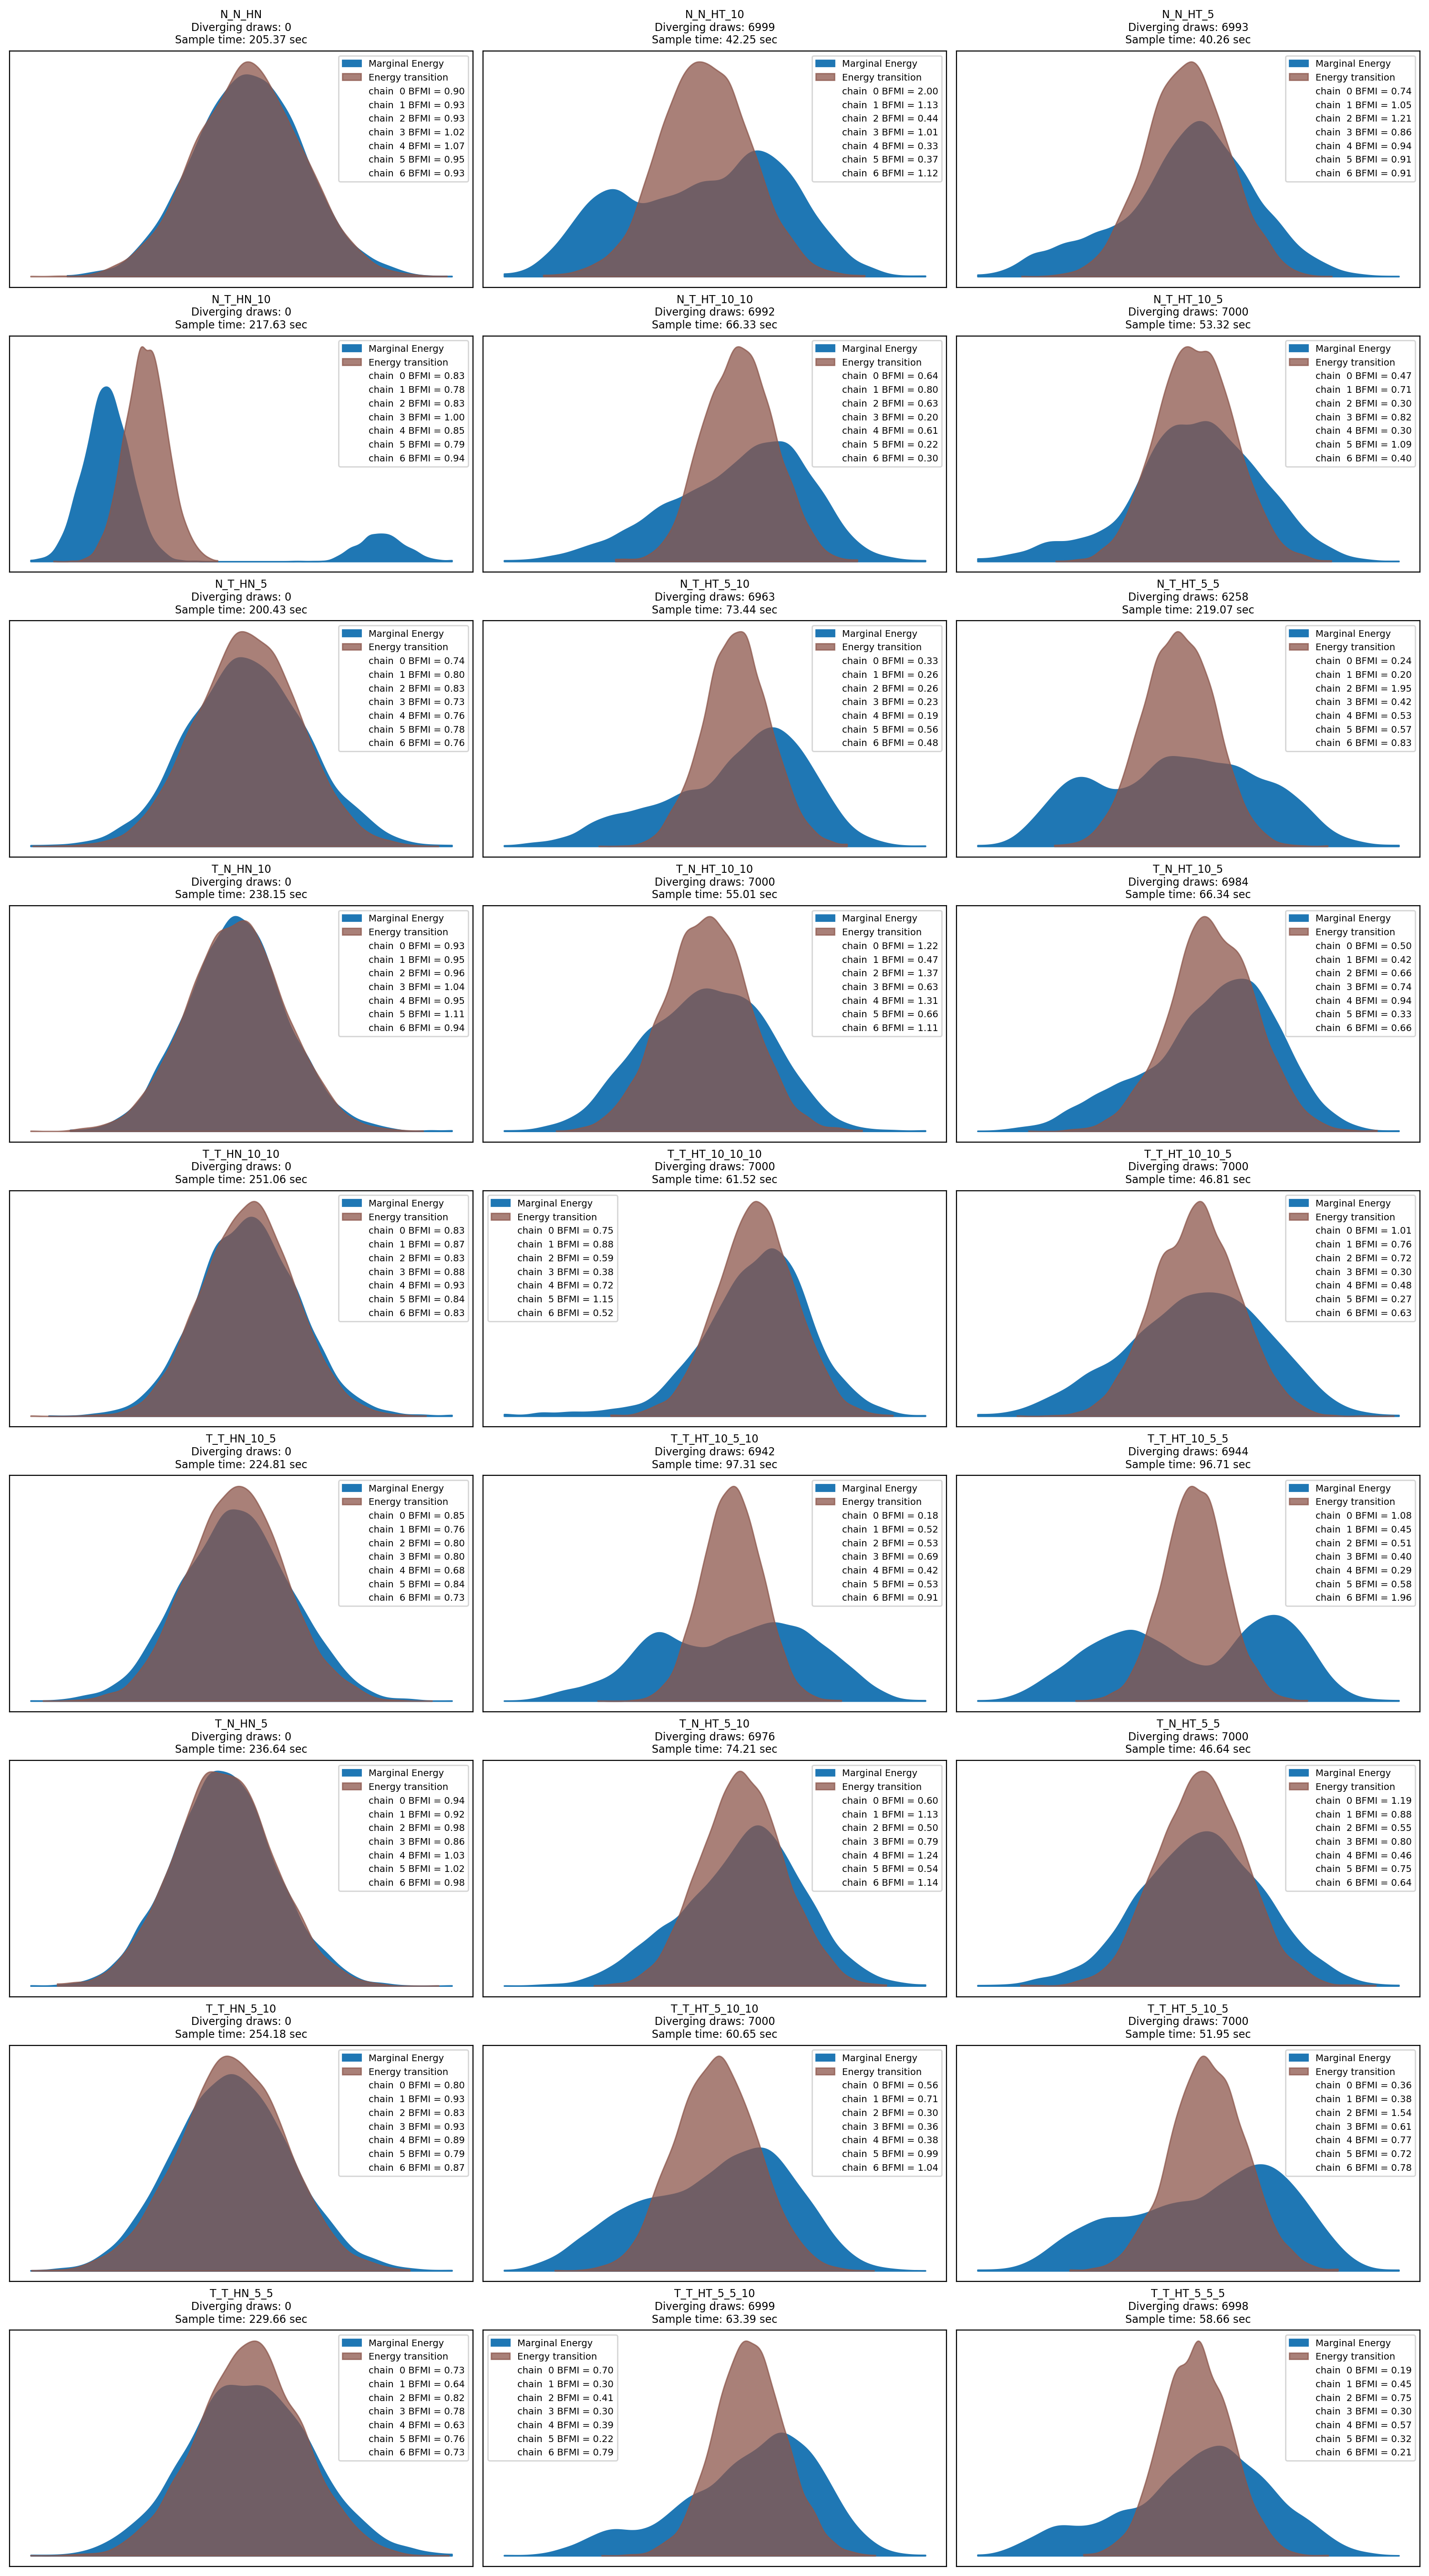

In [13]:
from math import ceil

# Plot the energy for all traces
ncol = 3
nrows = ceil(len(model_traces) / ncol)
f, axs = plt.subplots(nrows=nrows, ncols=ncol, figsize=(15, 3*nrows))
axs = axs.flatten()

for i, (name, d) in enumerate(model_traces.items()):

    ax = axs[i]
    az.plot_energy(d['trace'], ax=ax)
    ax.set_title(name + "\n" + 
                 f"Diverging draws: {d['trace'].sample_stats.diverging.sum().values}\n" +
                 f"Sample time: {d['trace'].sample_stats.sampling_time:.2f} sec"    
    )

# Remove empty subplots
[f.delaxes(ax) for ax in axs if not ax.has_data()]

plt.tight_layout()

# az.plot_energy(test_trace);


In [14]:
# Combine into InferenceData comparison object
loo_dict = {name: model_traces[name]['scores']['loo'] for name in model_traces.keys()}
cmp_df = az.compare(loo_dict, method="stacking", ic="loo")

# Save the comparison DataFrame
cmp_df.to_csv("../results/model_comparison.csv", )
# Print the comparison DataFrame
print("\nModel Comparison Results:")
cmp_df


Model Comparison Results:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
N_T_HT_5_10,0,-358.452110,62.930324,0.000000,4.765703e-01,26.860618,0.000000,True,log
N_N_HT_10,1,-359.459620,65.393423,1.007510,2.252832e-01,26.771997,3.069303,True,log
N_T_HT_10_5,2,-361.000076,66.023840,2.547967,2.724386e-08,26.918152,3.289561,True,log
N_T_HT_10_10,3,-361.222374,65.823139,2.770264,9.981287e-02,27.320468,3.897161,True,log
T_T_HT_10_5_5,4,-363.641294,57.862940,5.189184,8.081423e-02,27.381287,4.840141,True,log
T_T_HT_10_5_10,5,-364.153489,61.305255,5.701379,1.175195e-01,27.850611,5.006629,True,log
T_N_HT_10_5,6,-368.051247,64.387889,9.599137,3.166623e-08,27.337736,4.930719,True,log
T_N_HT_10_10,7,-368.332451,65.708143,9.880341,3.003514e-08,27.584315,4.323734,True,log
T_T_HT_10_10_10,8,-368.842565,61.994153,10.390455,3.140541e-08,27.010677,4.743943,True,log
N_N_HT_5,9,-373.748497,75.827076,15.296387,2.680213e-08,27.183989,4.619605,True,log


#### Import and analyze the results

In [4]:
import pandas as pd
import arviz as az
from pathlib import Path
from cloudpickle import load
from glob import glob

# Load models
model_traces = {}
for pkl in glob("../results/models/*.pkl"):
    name = Path(pkl).name.removesuffix("_model.pkl")
    trace_path = f"../results/traces/{name}_trace.nc"
    model_traces[name] = {}
    with open(pkl, "rb") as f:
        model_traces[name]['model'] = load(f)
    model_traces[name]['trace'] = az.from_netcdf(trace_path)

# Load the comparison DataFrame
cmp_df = pd.read_csv("../results/model_comparison.csv", index_col=0)



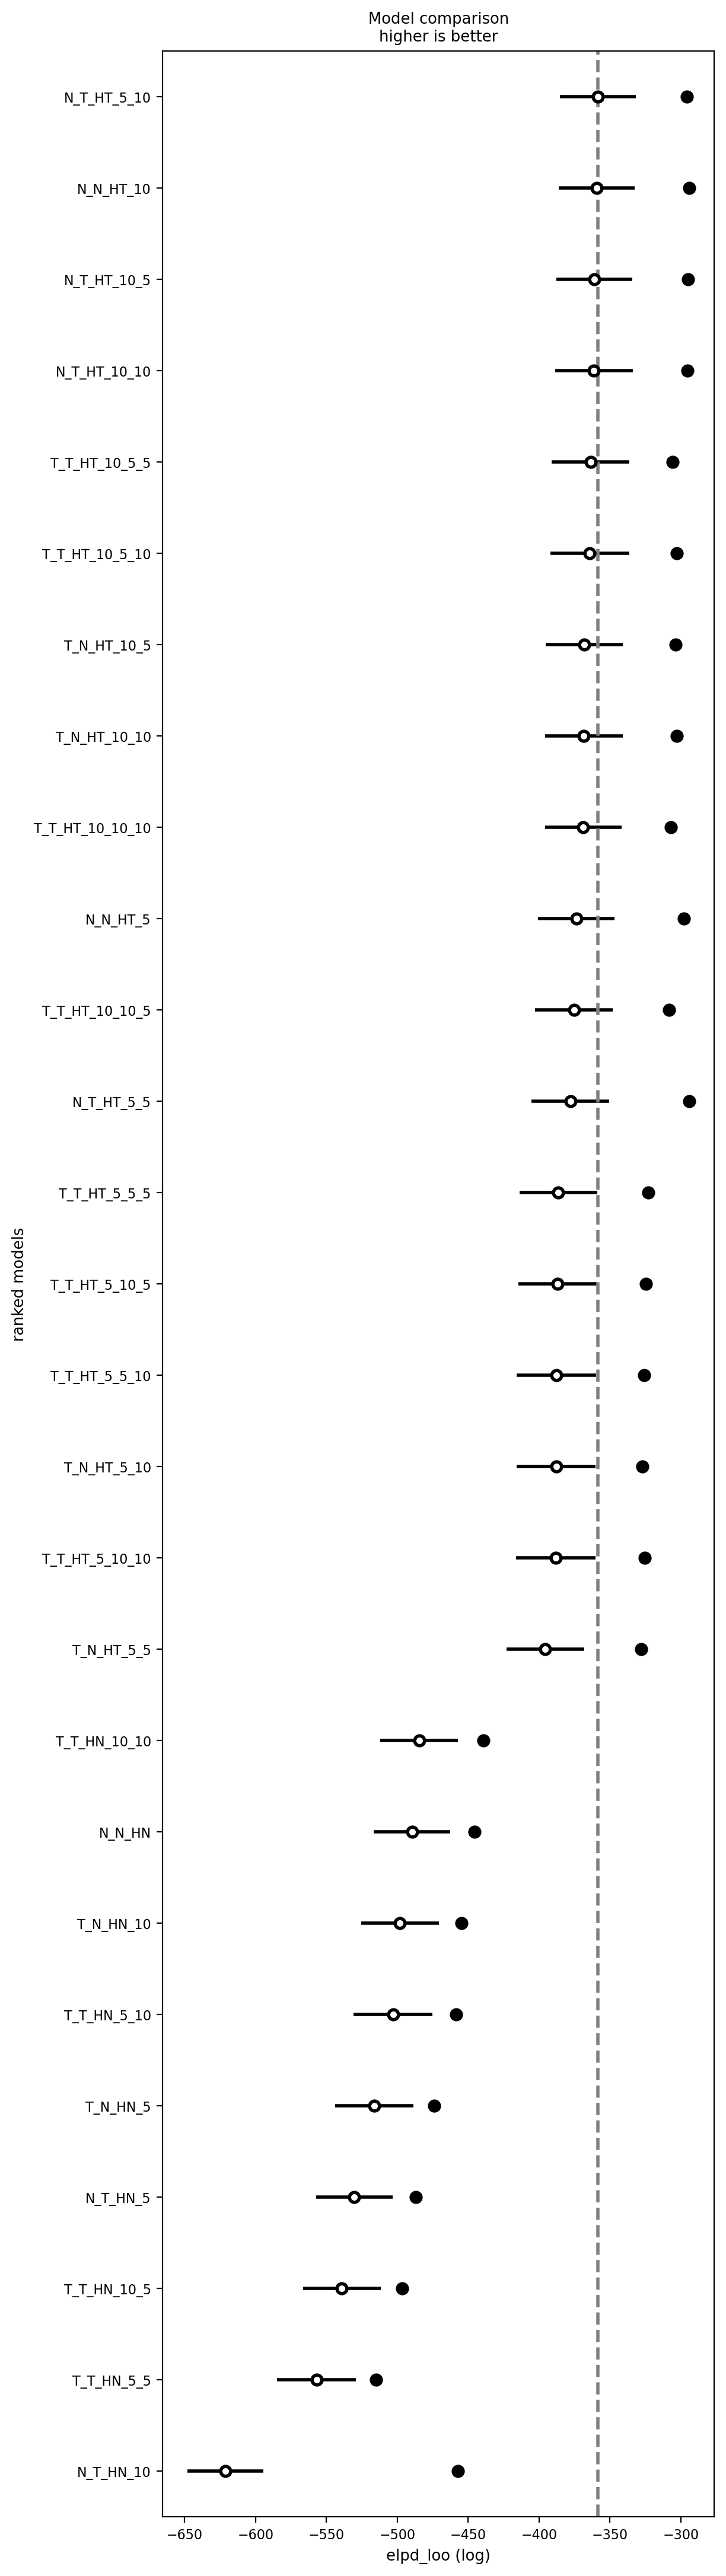

In [10]:
az.plot_compare(cmp_df, textsize=8, insample_dev=True);

/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/sojern/miniconda3/envs/pymc/lib/python3.13/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(a

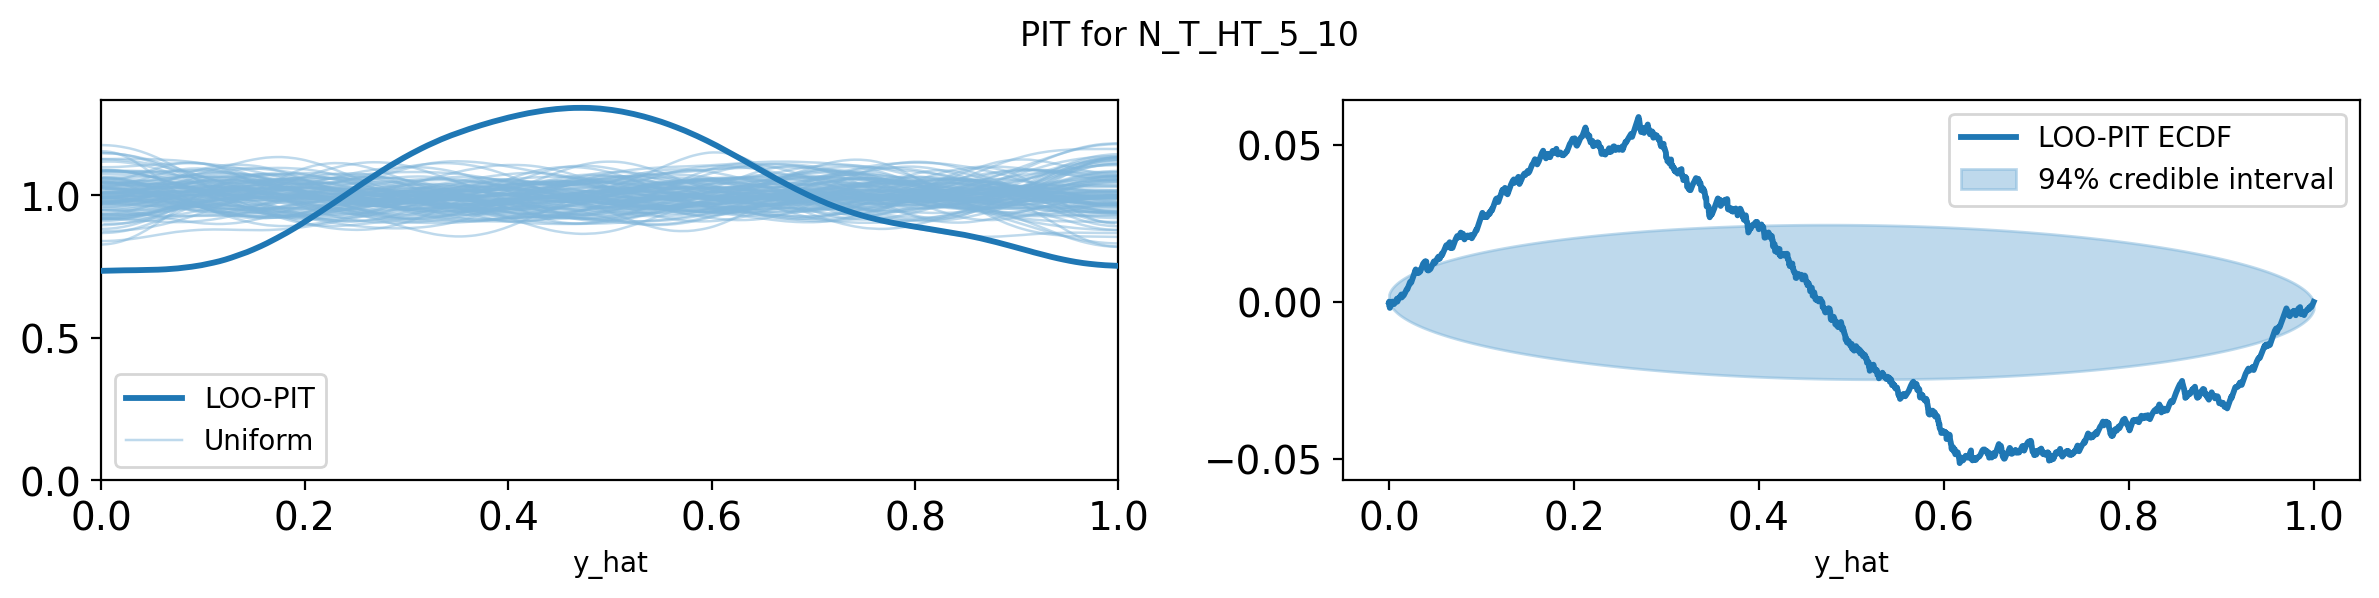

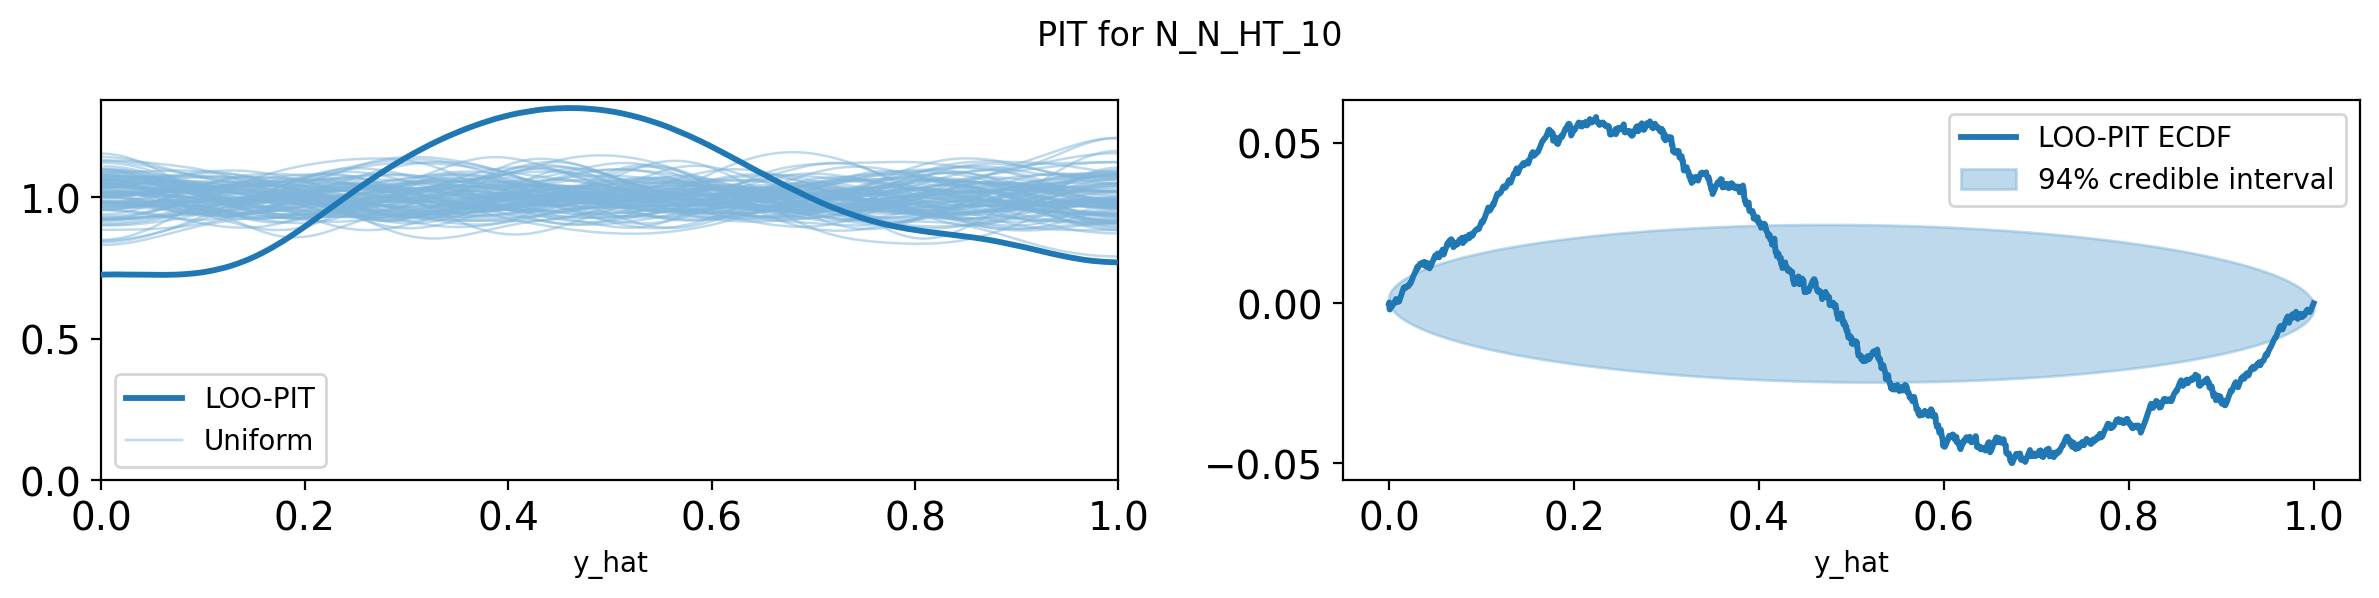

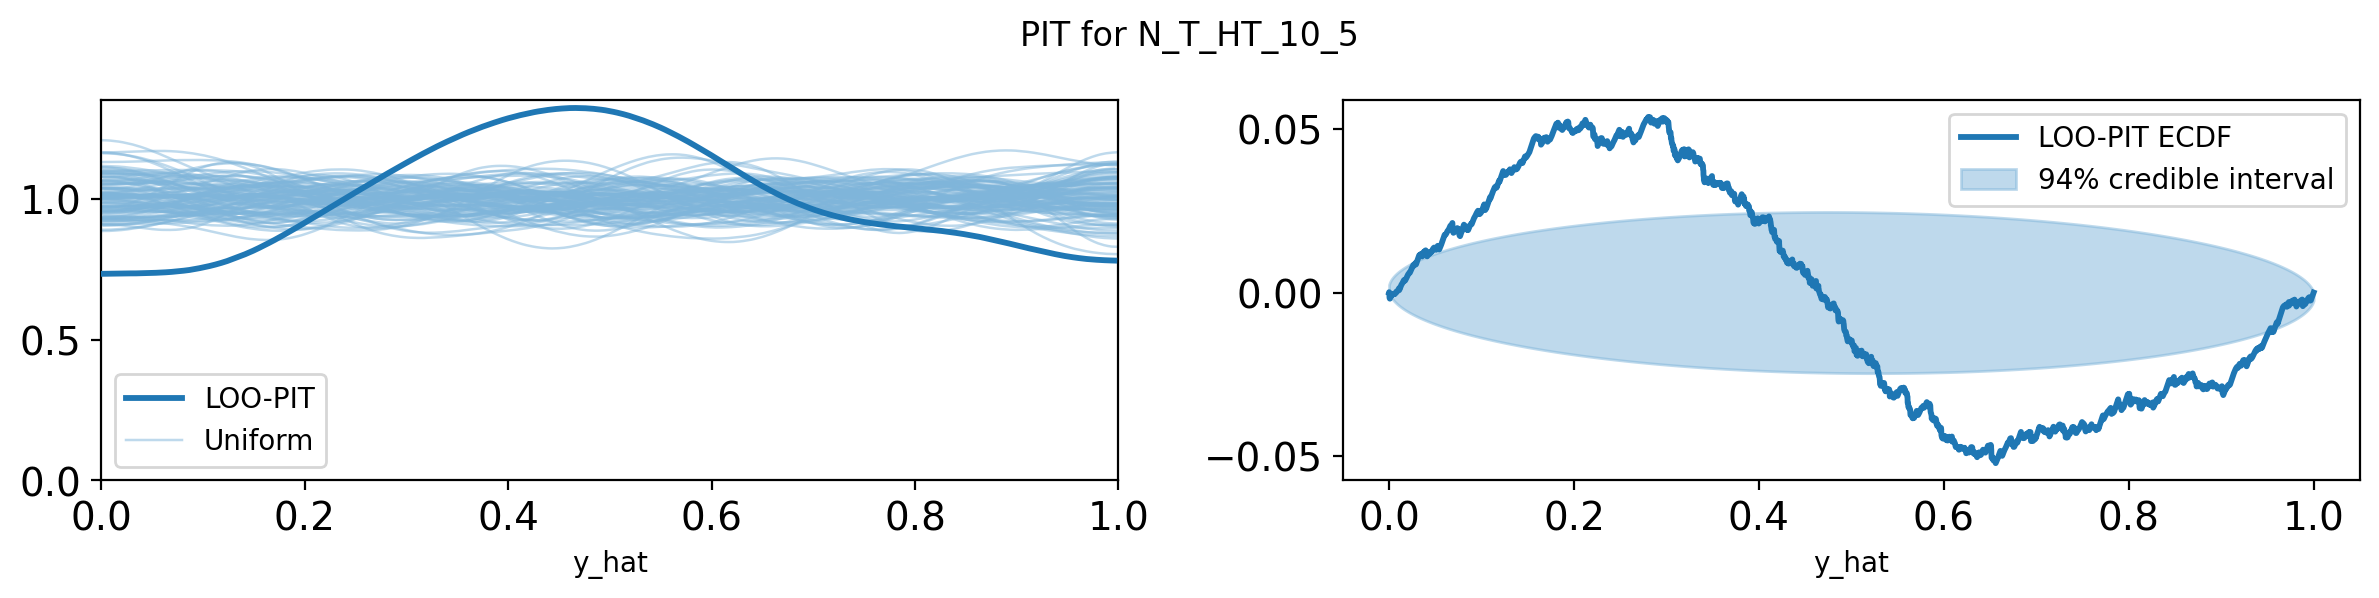

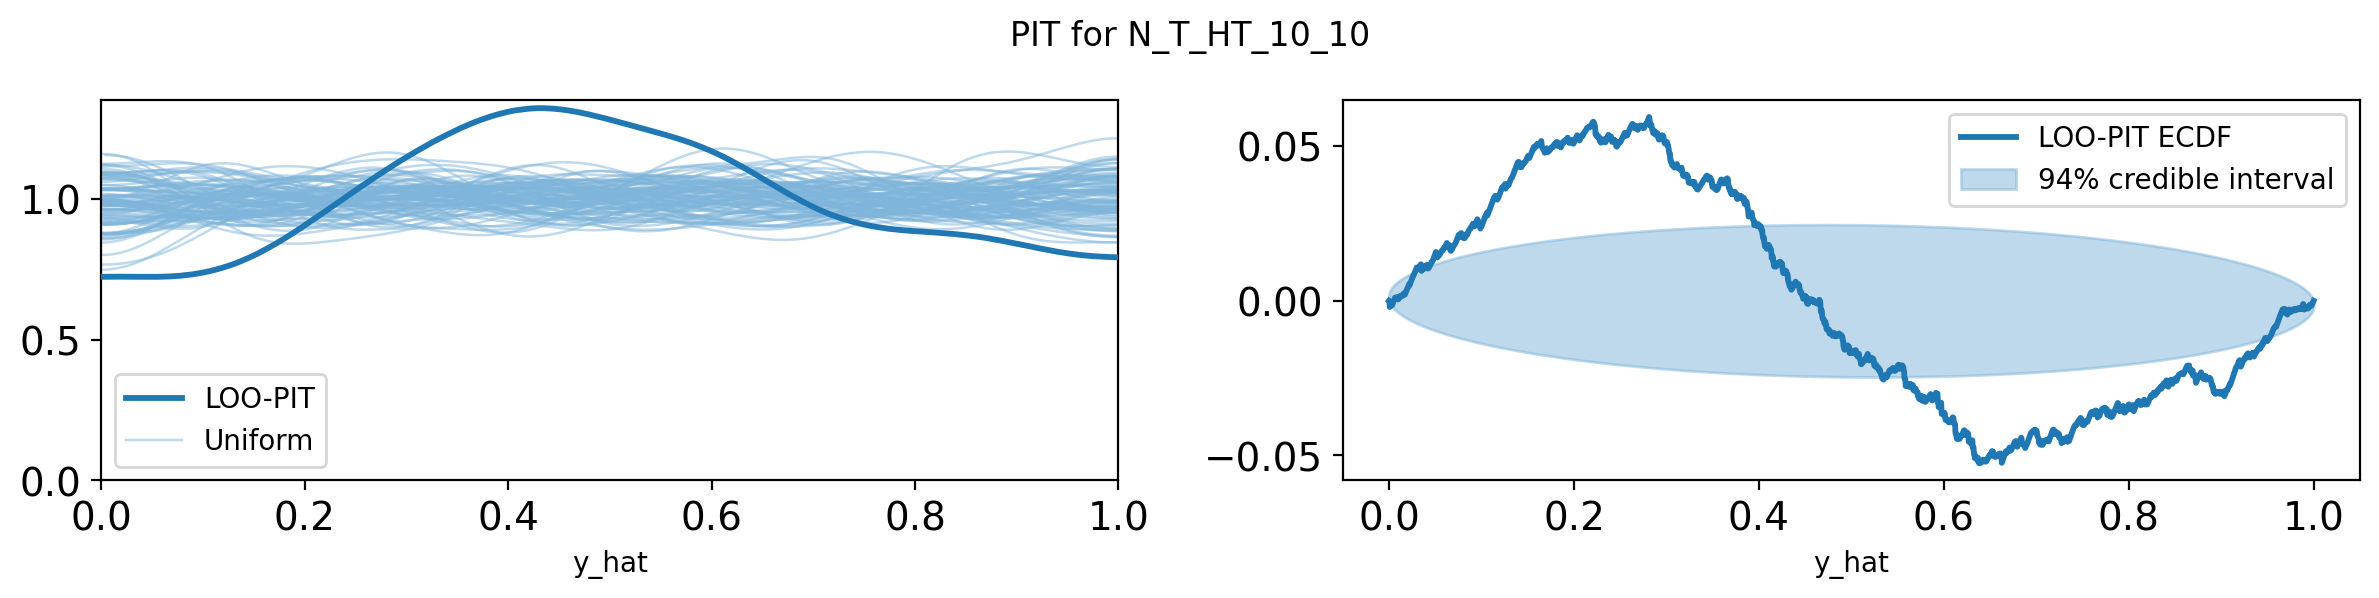

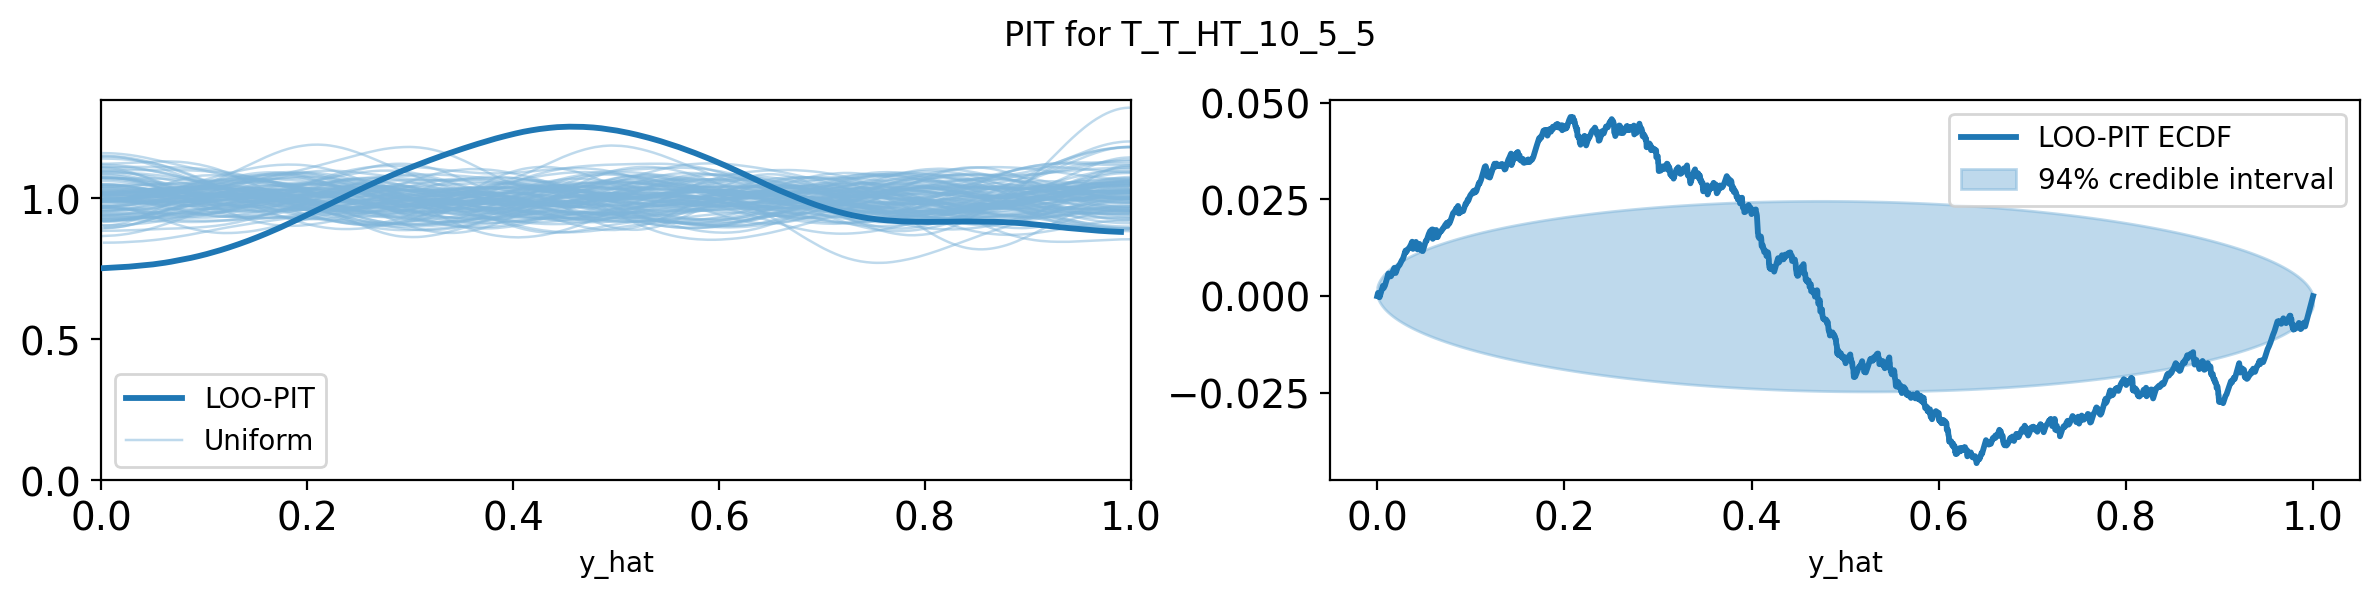

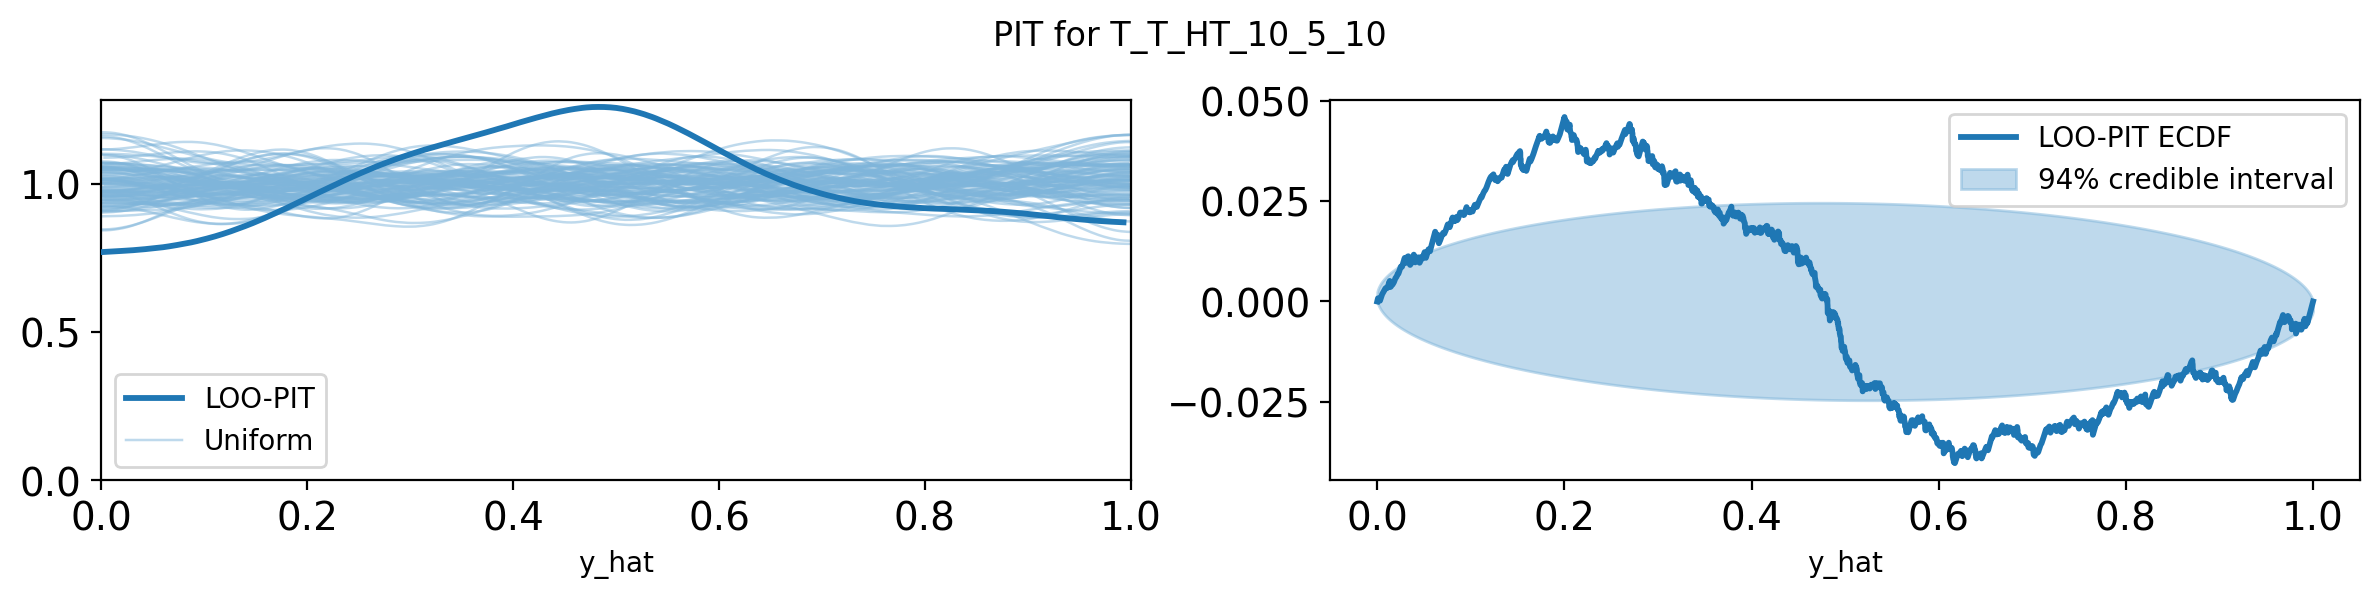

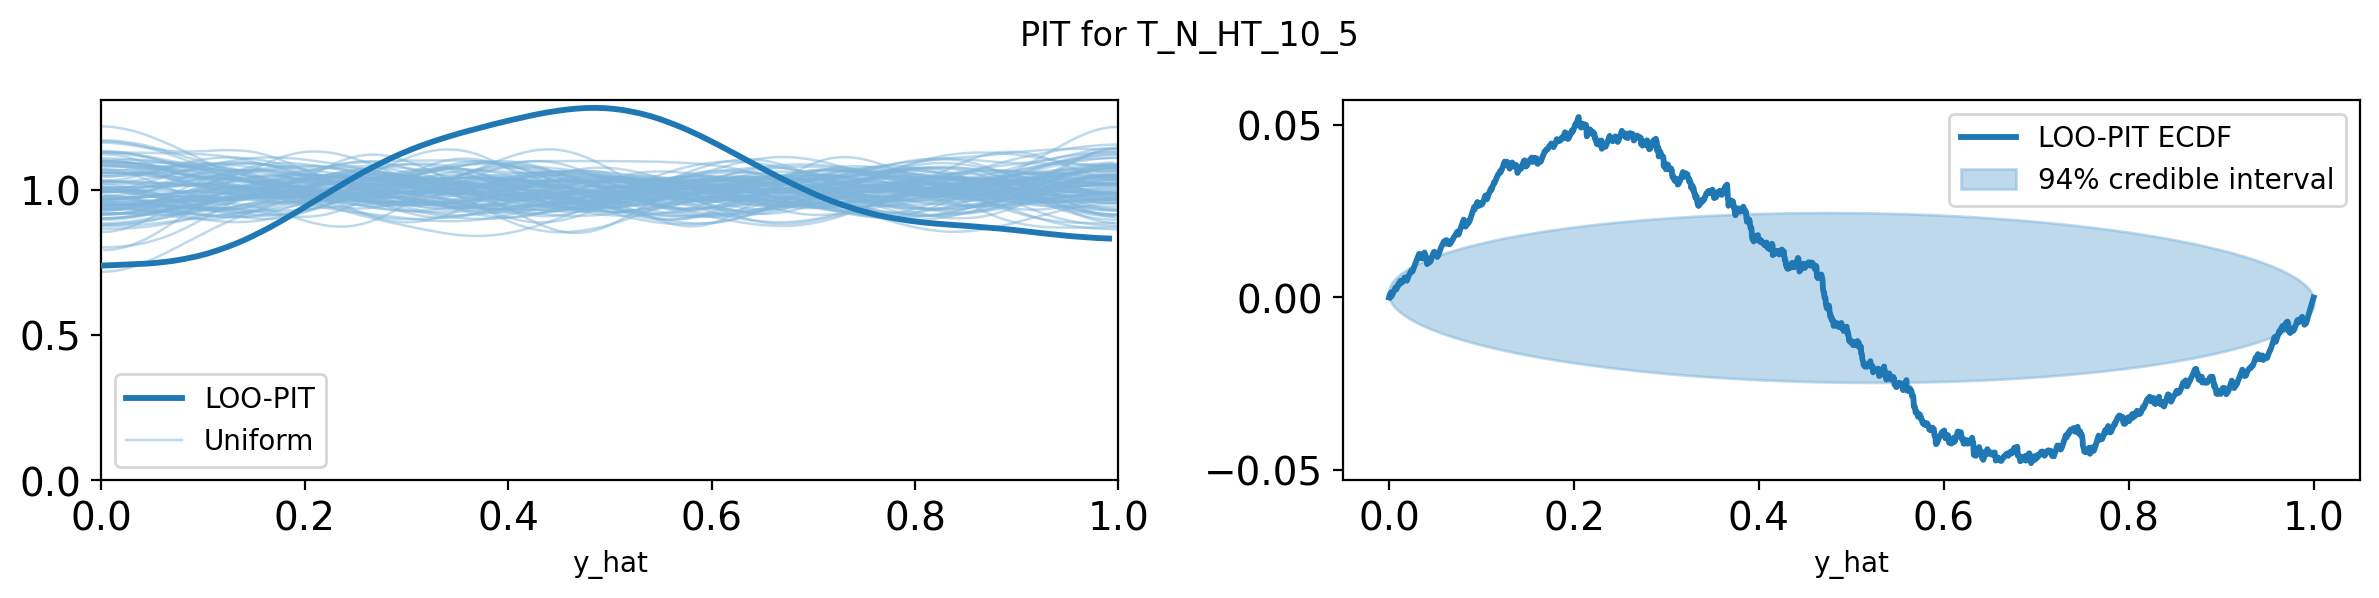

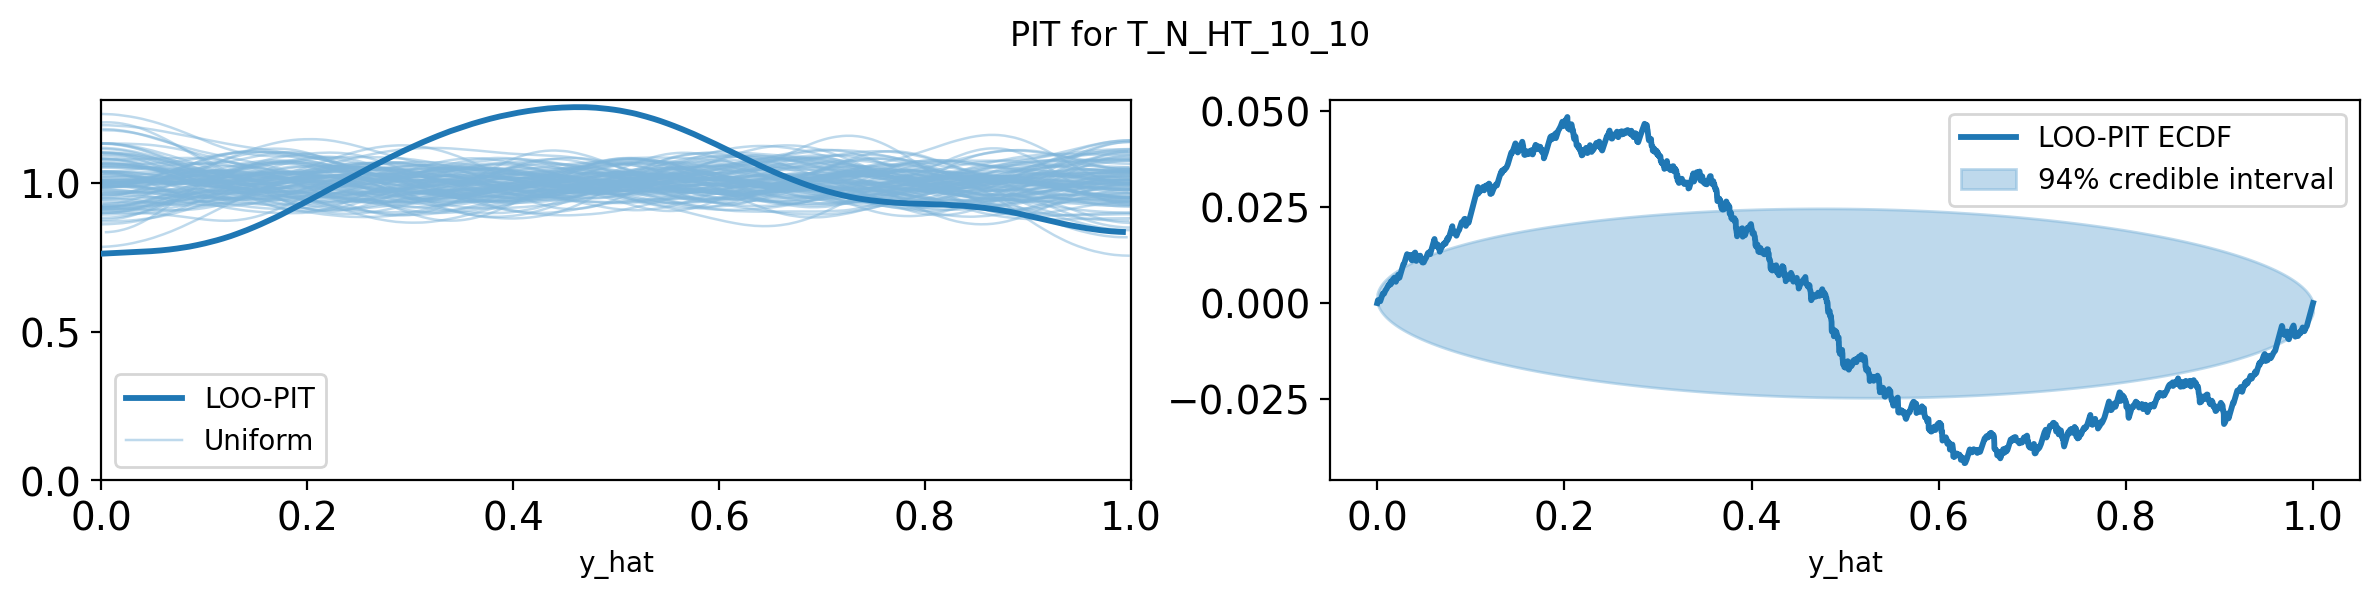

In [10]:
import matplotlib.pyplot as plt

top_n = 8


for name in cmp_df.index[:top_n]:
    f, axs = plt.subplots(1,2, figsize=(12, 3))
    trace = model_traces[name]['trace']
    az.plot_loo_pit(trace, y='y_hat', ax=axs[0])
    az.plot_loo_pit(trace, y='y_hat', ecdf=True, ax=axs[1])
    f.suptitle(f"PIT for {name}")
    f.tight_layout()
